# Native NLCD Land-Cover Authoring and Controlled Manning Verification

This notebook creates independent baseline and modified copies of the
HEC-RAS Bald Eagle Creek example. Both copies receive the same
HEC-RAS-authored NLCD layer, Terrain50 association, geometry text
table, spatial-Manning settings, and native property-table
recomputation. The modified copy then changes only two class values:

- Deciduous Forest: 0.100 → 0.108
- Mixed Forest: 0.120 → 0.132

Both plans are solved after preparation. Acceptance requires
class-by-class input equality outside the targets, text/sidecar
agreement, identical cell topology, explicit active-cell accounting,
a full outer audit of regenerated face-table keys, solver-owned Manning
arrays, and a baseline-versus-modified WSE comparison.


## Native-first workflow contract

| Step | Canonical API | Acceptance evidence |
|---|---|---|
| Discover the 2D extent | `RasMap.get_geometry_layer_bounds()` | Equal baseline/modified project-coordinate bounds |
| Author both starter layers | `RasMap.add_landcover_layer()` | Equal native sidecars, TIFFs, and registrations |
| Synchronize geometry text | `GeomLandCover.replace_base_mannings_n()` | Class-by-class text/sidecar value agreement |
| Associate terrain and land cover | `RasMap.associate_geometry_layers()` | Terrain50 and the authored layer in both geometry HDFs |
| Recompute both starter geometries | `RasMap.recompute_property_tables()` | Same preparation sequence and spatial-Manning settings |
| Edit only the modified targets | `HdfLandCover.set_landcover_mannings_n()` | Exact target deltas and zero non-target deltas |
| Recompute and solve | `RasCmdr.compute_plan()` | Completed HEC-RAS runs with required final arrays |
| Compare final results | `HdfMesh` + `HdfResultsMesh` | Active-cell identity, face-key regeneration accounting, Manning deltas, and WSE response |

The native setter edits the HEC-RAS classification table; it does not
custom-author HDF datasets. A Python raster estimate is not used as
solver evidence.


In [1]:
from pathlib import Path
import logging
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (
        (candidate / "ras_commander" / "__init__.py").exists()
        and (candidate / "examples").exists()
    ):
        REPO_ROOT = candidate.resolve()
        break
else:
    raise RuntimeError("Could not locate the ras-commander checkout")

repo_root_string = str(REPO_ROOT)
if repo_root_string in sys.path:
    sys.path.remove(repo_root_string)
sys.path.insert(0, repo_root_string)

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, TwoSlopeNorm
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from shapely.geometry import box

from ras_commander import (
    GeomLandCover,
    RasCmdr,
    RasExamples,
    RasMap,
    init_ras_project,
)
from ras_commander.geom import GeomStorage
from ras_commander.geom.ManningsFromLandCover import ManningsFromLandCover
from ras_commander.hdf import (
    HdfBndry,
    HdfLandCover,
    HdfMesh,
    HdfResultsBreach,
    HdfResultsMesh,
    HdfStruc,
)

logging.getLogger("ras_commander").setLevel(logging.WARNING)
for logger_name in list(logging.root.manager.loggerDict):
    if logger_name.startswith("ras_commander"):
        logging.getLogger(logger_name).setLevel(logging.WARNING)

# HEC-RAS 7 bundles an older but usable PROJ database. Rasterio reports
# its missing layout-version metadata even when the project/source CRS
# match. The notebook checks both project extents and raster CRS, so the
# known metadata-only warning is suppressed for presentation.
logging.getLogger("rasterio._env").setLevel(logging.ERROR)

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 180,
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
    }
)

RAS_VERSION = "7.0"
PLAN_NUMBER = "03"
GEOMETRY_NUMBER = "09"
MESH_NAME = "BaldEagleCr"
AUTHORED_LAYER_NAME = "LandCover_NLCD_212"
AUTHORED_FILENAME = "LandCover_NLCD_212.hdf"
TERRAIN_LAYER_NAME = "Terrain50"
BREACH_STRUCTURE = "BaldEagleCr Sayers Dam"
CELL_SIZE_FT = 100.0
BUFFER_FT = 500.0
NO_DATA_MANNING = 0.035
STARTER_MANNINGS = {
    "Deciduous Forest": 0.100,
    "Mixed Forest": 0.120,
}
TARGET_MANNINGS = {
    "Deciduous Forest": 0.108,
    "Mixed Forest": 0.132,
}

WORK_ROOT = REPO_ROOT / "working" / "notebook_runs" / "CLB-903" / "212"
WORK_ROOT.mkdir(parents=True, exist_ok=True)


def show_table(frame, formats=None):
    style = frame.style.hide(axis="index")
    if formats:
        style = style.format(formats)
    display(style)


## Project and hydraulic context

Plan 03 is an unsteady, single-2D-area dam-break model. An upstream
flow hydrograph enters BaldEagleCr, two normal-depth lines discharge
the domain, and a gate-opening schedule operates the internal Sayers
Dam connection. There is no stage-hydrograph boundary in this plan.

Baseline and modified projects are independent disposable copies.
Their plan, geometry, unsteady-flow file, simulation controls, source
NLCD raster, and Terrain50 association are held equal.


In [2]:
RasExamples.get_example_projects(RAS_VERSION)
project_paths = {
    "Baseline": Path(
        RasExamples.extract_project(
            "BaldEagleCrkMulti2D",
            output_path=WORK_ROOT,
            suffix="212_baseline",
        )
    ),
    "Modified": Path(
        RasExamples.extract_project(
            "BaldEagleCrkMulti2D",
            output_path=WORK_ROOT,
            suffix="212_modified",
        )
    ),
}
ras_objects = {
    label: init_ras_project(
        path,
        RAS_VERSION,
        ras_object="new",
        accept_tcu=True,
    )
    for label, path in project_paths.items()
}

scenarios = {}
for label, ras_object in ras_objects.items():
    plan = ras_object.plan_df.loc[
        ras_object.plan_df["plan_number"] == PLAN_NUMBER
    ].iloc[0]
    geom = ras_object.geom_df.loc[
        ras_object.geom_df["geom_number"] == GEOMETRY_NUMBER
    ].iloc[0]
    scenarios[label] = {
        "ras": ras_object,
        "path": project_paths[label],
        "plan": plan,
        "plan_hdf": project_paths[label]
        / f"{ras_object.project_name}.p{PLAN_NUMBER}.hdf",
        "geometry_path": Path(geom["full_path"]),
        "geometry_hdf": Path(geom["hdf_path"]),
        "source_nlcd": project_paths[label]
        / "Land Classification"
        / "LandCover.tif",
        "authored_hdf": project_paths[label]
        / "Land Classification"
        / AUTHORED_FILENAME,
    }

baseline_plan = scenarios["Baseline"]["plan"]
modified_plan = scenarios["Modified"]["plan"]
for field in [
    "Plan Title",
    "Simulation Date",
    "Computation Interval",
    "Mapping Interval",
    "unsteady_number",
]:
    assert baseline_plan[field] == modified_plan[field], field

flow_number = str(baseline_plan["unsteady_number"]).zfill(2)
boundary_context = ras_objects["Baseline"].boundaries_df.loc[
    ras_objects["Baseline"].boundaries_df["unsteady_number"] == flow_number,
    ["bc_type", "area_2d", "bc_line_name"],
].drop_duplicates()
expected_boundary_types = {"Flow Hydrograph", "Normal Depth", "Gate Opening"}
assert expected_boundary_types.issubset(set(boundary_context["bc_type"]))
assert "Stage Hydrograph" not in set(boundary_context["bc_type"])

context = pd.DataFrame(
    [
        ("HEC-RAS runtime", RAS_VERSION),
        ("plan", f"p{PLAN_NUMBER}: {baseline_plan['Plan Title']}"),
        ("geometry", f"g{GEOMETRY_NUMBER}"),
        ("unsteady flow", f"u{flow_number}"),
        ("2D flow area", MESH_NAME),
        ("simulation period", baseline_plan["Simulation Date"]),
        ("computation interval", baseline_plan["Computation Interval"]),
        ("mapping interval", baseline_plan["Mapping Interval"]),
    ],
    columns=["item", "value"],
)
show_table(context)
show_table(
    boundary_context.rename(
        columns={
            "bc_type": "boundary type",
            "area_2d": "2D area",
            "bc_line_name": "boundary/operation name",
        }
    ).reset_index(drop=True)
)


item,value
HEC-RAS runtime,7.0
plan,p03: Single 2D Area - Internal Dam Structure
geometry,g09
unsteady flow,u13
2D flow area,BaldEagleCr
simulation period,"01JAN1999,1200,04JAN1999,1200"
computation interval,30SEC
mapping interval,10MIN


boundary type,2D area,boundary/operation name
Normal Depth,BaldEagleCr,DSNormalDepth
Normal Depth,BaldEagleCr,DS2NormalD
Flow Hydrograph,BaldEagleCr,Upstream Inflow
Gate Opening,,


## Identical starter classification and polygon extents

Both copies use the same default NLCD classification, including the
same starter target values. Each native authoring call receives the
corresponding 2D bounding polygon and a 500-ft project-CRS buffer.
The baseline and modified bounds must match exactly.


In [3]:
classification_table = (
    ManningsFromLandCover.default_landcover_classification_table(
        percent_impervious={
            11: 100.0,
            21: 10.0,
            22: 25.0,
            23: 55.0,
            24: 85.0,
        }
    )
)
for class_name, value in STARTER_MANNINGS.items():
    classification_table.loc[
        classification_table["class_name"] == class_name,
        "mannings_n",
    ] = value

bounds_by_scenario = {}
for label, state in scenarios.items():
    bounds = RasMap.get_geometry_layer_bounds(
        state["geometry_hdf"],
        layer_type="RASD2FlowArea",
    )
    assert bounds["has_bounds"], label
    bounds_by_scenario[label] = bounds
    state["extent_polygon"] = box(
        bounds["min_x"],
        bounds["min_y"],
        bounds["max_x"],
        bounds["max_y"],
    )

for key in ["min_x", "min_y", "max_x", "max_y", "width", "height"]:
    assert np.isclose(
        bounds_by_scenario["Baseline"][key],
        bounds_by_scenario["Modified"][key],
        atol=1.0e-6,
    ), key

target_starter = classification_table.loc[
    classification_table["class_name"].isin(STARTER_MANNINGS),
    ["source_value", "class_name", "mannings_n"],
].sort_values("source_value")
for row in target_starter.itertuples(index=False):
    assert np.isclose(
        row.mannings_n,
        STARTER_MANNINGS[row.class_name],
        atol=1.0e-9,
    )

extent_summary = pd.DataFrame(
    [
        {
            "extent width (ft)": bounds_by_scenario["Baseline"]["width"],
            "extent height (ft)": bounds_by_scenario["Baseline"]["height"],
            "buffer (ft)": BUFFER_FT,
            "starter classes": len(classification_table),
        }
    ]
)
show_table(
    extent_summary,
    {
        "extent width (ft)": "{:,.1f}",
        "extent height (ft)": "{:,.1f}",
        "buffer (ft)": "{:,.0f}",
        "starter classes": "{:,.0f}",
    },
)
show_table(target_starter, {"mannings_n": "{:.3f}"})


extent width (ft),extent height (ft),buffer (ft),starter classes
"118,808.4","81,429.5",500,20


source_value,class_name,mannings_n
41,Deciduous Forest,0.100
43,Mixed Forest,0.120


## Native authoring in both projects

`add_landcover_layer()` delegates HDF and TIFF creation to the selected
HEC-RAS RASMapper library. The two native readbacks must contain
identical pixel values, class names, Manning values, and registration
metadata before any sensitivity edit occurs.


In [4]:
for label, state in scenarios.items():
    authored_hdf = RasMap.add_landcover_layer(
        state["path"],
        state["source_nlcd"],
        classification_table.copy(),
        cell_size=CELL_SIZE_FT,
        output_hdf_path=state["authored_hdf"],
        restrict_to_extent=state["extent_polygon"],
        buffer_distance=BUFFER_FT,
        layer_name=AUTHORED_LAYER_NAME,
        hecras_version=RAS_VERSION,
        ras_object=state["ras"],
    )
    assert authored_hdf == state["authored_hdf"]
    state["authored_tif"] = authored_hdf.with_suffix(".tif")
    state["starter_map"] = HdfLandCover.get_landcover_raster_map(
        authored_hdf
    )

    registered = RasMap.list_landcover_layers(
        state["path"],
        ras_object=state["ras"],
    )
    registered = registered.loc[
        registered["resolved_path"].map(Path) == authored_hdf
    ]
    assert len(registered) == 1
    assert registered.iloc[0]["classification_kind"] == "landcover"
    state["registration"] = registered.iloc[0]

starter_comparison = scenarios["Baseline"]["starter_map"][
    ["pixel_value", "class_name", "mannings_n"]
].merge(
    scenarios["Modified"]["starter_map"][
        ["pixel_value", "class_name", "mannings_n"]
    ],
    on=["pixel_value", "class_name"],
    how="outer",
    suffixes=("_baseline", "_modified"),
    indicator=True,
    validate="one_to_one",
)
assert starter_comparison["_merge"].eq("both").all()
np.testing.assert_allclose(
    starter_comparison["mannings_n_baseline"],
    starter_comparison["mannings_n_modified"],
    rtol=0.0,
    atol=1.0e-9,
)

starter_targets = starter_comparison.loc[
    starter_comparison["class_name"].isin(STARTER_MANNINGS),
    [
        "pixel_value",
        "class_name",
        "mannings_n_baseline",
        "mannings_n_modified",
    ],
]
authoring_summary = pd.DataFrame(
    [
        {
            "scenario": label,
            "sidecar": state["authored_hdf"].name,
            "TIFF": state["authored_tif"].name,
            "registered layer": state["registration"]["name"],
            "class rows": len(state["starter_map"]),
        }
        for label, state in scenarios.items()
    ]
)
show_table(authoring_summary, {"class rows": "{:,.0f}"})
show_table(
    starter_targets,
    {
        "mannings_n_baseline": "{:.3f}",
        "mannings_n_modified": "{:.3f}",
    },
)


scenario,sidecar,TIFF,registered layer,class rows
Baseline,LandCover_NLCD_212.hdf,LandCover_NLCD_212.tif,LandCover_NLCD_212,21
Modified,LandCover_NLCD_212.hdf,LandCover_NLCD_212.tif,LandCover_NLCD_212,21


pixel_value,class_name,mannings_n_baseline,mannings_n_modified
41,Deciduous Forest,0.100,0.100
43,Mixed Forest,0.120,0.120


## Synchronize, associate, and recompute both starter geometries

Each geometry text table is derived from its own native sidecar
readback. HEC-RAS stores a non-hydraulic NoData sentinel in the
sidecar; the geometry table uses the documented 0.035 fallback for
that row. Every hydraulic class must otherwise match exactly.

Spatially varied face Manning and composite classification are enabled
identically. Each geometry is associated with its copy of Terrain50
and its authored land-cover sidecar before native recomputation.


In [5]:
def geometry_table_from_sidecar(sidecar_map):
    table = sidecar_map[["class_name", "mannings_n"]].copy()
    table["mannings_n"] = pd.to_numeric(
        table["mannings_n"],
        errors="raise",
    )
    table.loc[
        table["class_name"].eq("NoData"),
        "mannings_n",
    ] = NO_DATA_MANNING
    assert table["class_name"].is_unique
    return table.rename(
        columns={
            "class_name": "Land Cover Name",
            "mannings_n": "Base Mannings n Value",
        }
    )


def assert_text_sidecar_equal(geometry_path, sidecar_map):
    expected = geometry_table_from_sidecar(sidecar_map)
    observed = GeomLandCover.get_base_mannings_n(geometry_path)[
        ["Land Cover Name", "Base Mannings n Value"]
    ]
    comparison = expected.merge(
        observed,
        on="Land Cover Name",
        how="outer",
        suffixes=("_sidecar", "_text"),
        indicator=True,
        validate="one_to_one",
    )
    assert comparison["_merge"].eq("both").all()
    np.testing.assert_allclose(
        comparison["Base Mannings n Value_sidecar"],
        comparison["Base Mannings n Value_text"],
        rtol=0.0,
        atol=1.0e-6,
    )
    return comparison


preparation_rows = []
for label, state in scenarios.items():
    geometry_table = geometry_table_from_sidecar(state["starter_map"])
    assert GeomLandCover.replace_base_mannings_n(
        state["geometry_path"],
        geometry_table,
    )
    text_check = assert_text_sidecar_equal(
        state["geometry_path"],
        state["starter_map"],
    )

    GeomStorage.set_2d_flow_area_settings(
        state["geometry_path"],
        MESH_NAME,
        spatially_varied_mann_on_faces=True,
        composite_classification=True,
    )
    settings = GeomStorage.get_2d_flow_area_settings(
        state["geometry_path"]
    )
    area_settings = settings.loc[settings["name"] == MESH_NAME].iloc[0]
    assert bool(area_settings["spatially_varied_mann_on_faces"])
    assert bool(area_settings["composite_classification"])

    terrain_layers = RasMap.list_terrain_layers(
        state["path"],
        ras_object=state["ras"],
    )
    terrain_row = terrain_layers.loc[
        terrain_layers["name"] == TERRAIN_LAYER_NAME
    ].iloc[0]
    terrain_hdf = Path(terrain_row["resolved_path"])
    state["terrain_hdf"] = terrain_hdf

    RasMap.associate_geometry_layers(
        state["path"],
        state["geometry_hdf"],
        landcover_hdf_path=state["authored_hdf"],
        terrain_hdf_path=terrain_hdf,
        hecras_version=RAS_VERSION,
        ras_object=state["ras"],
    )
    association = RasMap.get_hdf_geometry_association(
        state["geometry_hdf"]
    )
    assert Path(association["landcover_hdf_path"]) == state["authored_hdf"]
    assert Path(association["terrain_hdf_path"]) == terrain_hdf
    assert association["terrain_layer_name"] == TERRAIN_LAYER_NAME
    state["association"] = association

    recomputed_hdf = RasMap.recompute_property_tables(
        state["path"],
        state["geometry_hdf"],
        hecras_version=RAS_VERSION,
        audit_mannings=True,
        ras_object=state["ras"],
    )
    assert recomputed_hdf == state["geometry_hdf"]
    preparation_rows.append(
        {
            "scenario": label,
            "text/sidecar classes verified": len(text_check),
            "terrain": association["terrain_layer_name"],
            "land cover": association["landcover_layer_name"],
            "spatial face n": True,
            "composite classification": True,
            "native recompute": "complete",
        }
    )

assert (
    scenarios["Baseline"]["association"]["terrain_layer_name"]
    == scenarios["Modified"]["association"]["terrain_layer_name"]
    == TERRAIN_LAYER_NAME
)
show_table(
    pd.DataFrame(preparation_rows),
    {"text/sidecar classes verified": "{:,.0f}"},
)


scenario,text/sidecar classes verified,terrain,land cover,spatial face n,composite classification,native recompute
Baseline,21,Terrain50,LandCover_NLCD_212,True,True,complete
Modified,21,Terrain50,LandCover_NLCD_212,True,True,complete


## Engineering overview

The overview combines public HDF readers for the 2D perimeter,
breaklines, boundary-condition lines, and internal structure with the
native starter land-cover TIFF. Target classes are marked in the
legend. Terrain50 is the associated terrain for the displayed mesh.


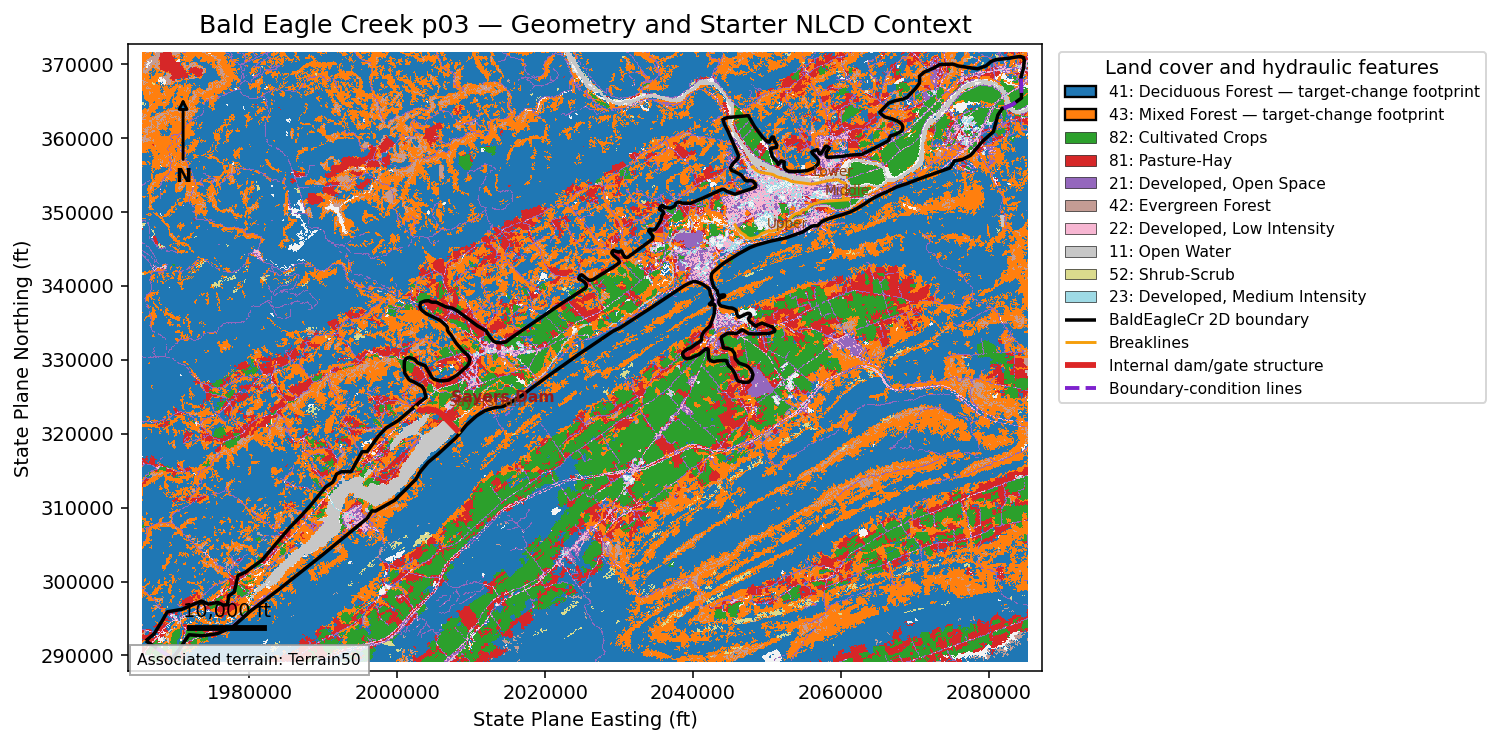

NLCD code,class,target edit,raster cells,area (acres)
41,Deciduous Forest,True,"451,768","103,711.7"
43,Mixed Forest,True,"235,749","54,120.5"
82,Cultivated Crops,False,"102,137","23,447.4"
81,Pasture-Hay,False,"76,947","17,664.6"
21,"Developed, Open Space",False,"50,803","11,662.8"
42,Evergreen Forest,False,"20,464","4,697.9"
22,"Developed, Low Intensity",False,"16,083","3,692.1"
11,Open Water,False,"14,682","3,370.5"
52,Shrub-Scrub,False,"4,474","1,027.1"
23,"Developed, Medium Intensity",False,"4,333",994.7


In [6]:
overview_hdf = scenarios["Baseline"]["geometry_hdf"]
mesh_areas = HdfMesh.get_mesh_areas(overview_hdf)
mesh_areas = mesh_areas.loc[mesh_areas["mesh_name"] == MESH_NAME]
bc_lines = HdfBndry.get_bc_lines(overview_hdf)
breaklines = HdfBndry.get_breaklines(overview_hdf)
structures = HdfStruc.get_structures(overview_hdf)
assert len(mesh_areas) == 1
assert not bc_lines.empty
assert not breaklines.empty
assert not structures.empty

with rasterio.open(scenarios["Baseline"]["authored_tif"]) as source:
    landcover = source.read(1)
    raster_bounds = source.bounds
    raster_crs = source.crs
assert raster_crs is not None

raster_map = scenarios["Baseline"]["starter_map"]
class_names = dict(
    zip(raster_map["pixel_value"], raster_map["class_name"])
)
values, counts = np.unique(landcover, return_counts=True)
ranked = sorted(
    [
        (int(value), int(count))
        for value, count in zip(values, counts)
        if int(value) != 0
    ],
    key=lambda item: item[1],
    reverse=True,
)
top_codes = [value for value, _ in ranked[:10]]
display_values = np.zeros_like(landcover, dtype=np.int16)
for display_id, value in enumerate(top_codes, start=1):
    display_values[landcover == value] = display_id

colors = ["#f3f3f3", *plt.cm.tab20(np.linspace(0, 1, len(top_codes)))]
cmap = ListedColormap(colors)
fig, ax = plt.subplots(figsize=(13, 8))
ax.imshow(
    display_values,
    extent=(
        raster_bounds.left,
        raster_bounds.right,
        raster_bounds.bottom,
        raster_bounds.top,
    ),
    origin="upper",
    cmap=cmap,
    interpolation="nearest",
)

mesh_areas.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.8,
    label="BaldEagleCr 2D boundary",
)
breaklines.plot(
    ax=ax,
    color="#f59e0b",
    linewidth=1.5,
    label="Breaklines",
)
structures.plot(
    ax=ax,
    color="#dc2626",
    linewidth=3.0,
    label="Internal dam/gate structure",
)
bc_lines.plot(
    ax=ax,
    color="#7e22ce",
    linewidth=2.0,
    linestyle="--",
    label="Boundary-condition lines",
)

for row in breaklines.itertuples():
    point = row.geometry.interpolate(0.5, normalized=True)
    ax.annotate(
        row.Name,
        (point.x, point.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7,
        color="#92400e",
    )
# Boundary names are tabulated above. Omitting repeated map labels keeps
# the long exterior lines from producing clipped or overlapping text.
for row in structures.itertuples():
    point = row.geometry.interpolate(0.5, normalized=True)
    ax.annotate(
        row.Connection or "Internal structure",
        (point.x, point.y),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=8,
        color="#991b1b",
        fontweight="bold",
    )

landcover_handles = []
for index, value in enumerate(top_codes):
    class_name = class_names.get(value, "Unknown")
    suffix = (
        " — target-change footprint"
        if class_name in TARGET_MANNINGS
        else ""
    )
    landcover_handles.append(
        Patch(
            facecolor=colors[index + 1],
            edgecolor="black",
            linewidth=1.2 if suffix else 0.3,
            label=f"{value}: {class_name}{suffix}",
        )
    )
feature_handles, feature_labels = ax.get_legend_handles_labels()
ax.legend(
    handles=[*landcover_handles, *feature_handles],
    labels=[
        *[handle.get_label() for handle in landcover_handles],
        *feature_labels,
    ],
    title="Land cover and hydraulic features",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
)

min_x, min_y, max_x, max_y = mesh_areas.total_bounds
pad_x = 0.02 * (max_x - min_x)
pad_y = 0.02 * (max_y - min_y)
ax.set_xlim(min_x - pad_x, max_x + pad_x)
ax.set_ylim(min_y - pad_y, max_y + pad_y)
ax.set_title("Bald Eagle Creek p03 — Geometry and Starter NLCD Context")
ax.set_xlabel("State Plane Easting (ft)")
ax.set_ylabel("State Plane Northing (ft)")
ax.ticklabel_format(style="plain", useOffset=False)
ax.set_aspect("equal")
ax.annotate(
    "N",
    xy=(0.06, 0.92),
    xytext=(0.06, 0.78),
    xycoords="axes fraction",
    ha="center",
    fontweight="bold",
    arrowprops={"arrowstyle": "-|>", "linewidth": 1.5},
)
scale = 10_000.0
x0 = min_x + 0.05 * (max_x - min_x)
y0 = min_y + 0.05 * (max_y - min_y)
ax.plot([x0, x0 + scale], [y0, y0], color="black", linewidth=3)
ax.text(x0 + scale / 2, y0 + pad_y, "10,000 ft", ha="center")
ax.text(
    0.01,
    0.01,
    "Associated terrain: Terrain50",
    transform=ax.transAxes,
    fontsize=8,
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.6"},
)
plt.tight_layout(rect=[0, 0, 0.75, 1])
plt.show()

area_summary = pd.DataFrame(
    [
        {
            "NLCD code": value,
            "class": class_names.get(value, "Unknown"),
            "target edit": class_names.get(value) in TARGET_MANNINGS,
            "raster cells": count,
            "area (acres)": count * CELL_SIZE_FT**2 / 43_560.0,
        }
        for value, count in ranked[:12]
    ]
)
show_table(
    area_summary,
    {
        "raster cells": "{:,.0f}",
        "area (acres)": "{:,.1f}",
    },
)


## Modify only two classes, resynchronize, and recompute

The baseline remains at the starter values. The modified native
sidecar changes only Deciduous Forest and Mixed Forest. A full outer
class comparison proves exact target deltas and zero non-target
deltas. The modified geometry text table is then rebuilt from the
post-edit sidecar readback and verified numerically before the second
native recomputation.


In [7]:
modified_state = scenarios["Modified"]
parameter_report = HdfLandCover.set_landcover_mannings_n(
    modified_state["authored_hdf"],
    TARGET_MANNINGS,
    hecras_version=RAS_VERSION,
    ras_object=modified_state["ras"],
)
assert Path(parameter_report["backup_path"]).exists()
assert parameter_report["recompute_required"] is True
assert int(parameter_report["changed"]) == len(TARGET_MANNINGS)

modified_map = HdfLandCover.get_landcover_raster_map(
    modified_state["authored_hdf"]
)
baseline_map = scenarios["Baseline"]["starter_map"]
class_comparison = baseline_map[
    ["pixel_value", "class_name", "mannings_n"]
].merge(
    modified_map[["pixel_value", "class_name", "mannings_n"]],
    on=["pixel_value", "class_name"],
    how="outer",
    suffixes=("_baseline", "_modified"),
    indicator=True,
    validate="one_to_one",
)
assert class_comparison["_merge"].eq("both").all()
class_comparison["delta_n"] = (
    class_comparison["mannings_n_modified"]
    - class_comparison["mannings_n_baseline"]
)
class_comparison["target"] = class_comparison["class_name"].isin(
    TARGET_MANNINGS
)

nontarget = class_comparison.loc[~class_comparison["target"]]
np.testing.assert_allclose(
    nontarget["delta_n"],
    0.0,
    rtol=0.0,
    atol=1.0e-9,
)
for class_name, target_value in TARGET_MANNINGS.items():
    row = class_comparison.loc[
        class_comparison["class_name"] == class_name
    ].iloc[0]
    assert np.isclose(
        row["mannings_n_baseline"],
        STARTER_MANNINGS[class_name],
        atol=1.0e-9,
    )
    assert np.isclose(
        row["mannings_n_modified"],
        target_value,
        atol=1.0e-9,
    )
    assert np.isclose(
        row["delta_n"],
        target_value - STARTER_MANNINGS[class_name],
        atol=1.0e-9,
    )

modified_geometry_table = geometry_table_from_sidecar(modified_map)
assert GeomLandCover.replace_base_mannings_n(
    modified_state["geometry_path"],
    modified_geometry_table,
)
modified_text_check = assert_text_sidecar_equal(
    modified_state["geometry_path"],
    modified_map,
)
assert len(modified_text_check) == len(modified_map)

recomputed_hdf = RasMap.recompute_property_tables(
    modified_state["path"],
    modified_state["geometry_hdf"],
    hecras_version=RAS_VERSION,
    audit_mannings=True,
    ras_object=modified_state["ras"],
)
assert recomputed_hdf == modified_state["geometry_hdf"]
modified_state["final_map"] = modified_map

target_change_table = class_comparison.loc[
    class_comparison["target"],
    [
        "pixel_value",
        "class_name",
        "mannings_n_baseline",
        "mannings_n_modified",
        "delta_n",
    ],
].sort_values("pixel_value")
edit_summary = pd.DataFrame(
    [
        {
            "native changed rows": int(parameter_report["changed"]),
            "native unchanged rows": int(parameter_report["unchanged"]),
            "backup": Path(parameter_report["backup_path"]).name,
            "non-target deltas verified zero": len(nontarget),
            "text/sidecar rows verified": len(modified_text_check),
            "native recompute": "complete",
        }
    ]
)
show_table(
    target_change_table,
    {
        "mannings_n_baseline": "{:.3f}",
        "mannings_n_modified": "{:.3f}",
        "delta_n": "{:+.3f}",
    },
)
show_table(
    edit_summary,
    {
        "native changed rows": "{:,.0f}",
        "native unchanged rows": "{:,.0f}",
        "non-target deltas verified zero": "{:,.0f}",
        "text/sidecar rows verified": "{:,.0f}",
    },
)


pixel_value,class_name,mannings_n_baseline,mannings_n_modified,delta_n
41,Deciduous Forest,0.100,0.108,+0.008
43,Mixed Forest,0.120,0.132,+0.012


native changed rows,native unchanged rows,backup,non-target deltas verified zero,text/sidecar rows verified,native recompute
2,19,LandCover_NLCD_212.native_parameters.20260725_152629_679466.backup.hdf,19,21,complete


## Baseline solve

The baseline now contains the same authored layer and settings as the
modified project, but retains the starter class values. Required HDF
datasets prevent a successful process exit from being mistaken for a
complete hydraulic result.


In [8]:
baseline_state = scenarios["Baseline"]
baseline_plan_hdf = baseline_state["plan_hdf"]
baseline_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=baseline_state["ras"],
    force_rerun=True,
    num_cores=2,
    verify=True,
)
assert baseline_result.success, "Baseline HEC-RAS computation failed."
assert baseline_result.completion_verified is True

baseline_audit = HdfLandCover.audit_final_mannings_n(
    baseline_plan_hdf,
    mesh_name=MESH_NAME,
    tolerance=1.0e-4,
    expected_values=list(STARTER_MANNINGS.values()),
)
assert bool(baseline_audit.iloc[0]["passed"])
baseline_cells = HdfLandCover.get_preprocessed_mannings_n(
    baseline_plan_hdf,
    mesh_name=MESH_NAME,
).rename(columns={"mannings_n": "baseline_n"})
baseline_wse = HdfResultsMesh.get_mesh_max_ws(baseline_plan_hdf)

baseline_compute_summary = pd.DataFrame(
    [
        {
            "scenario": "Baseline",
            "plan": f"p{PLAN_NUMBER}",
            "success": bool(baseline_result.success),
            "completion verified": bool(
                baseline_result.completion_verified
            ),
            "cell Manning rows": int(
                baseline_audit.iloc[0]["cell_value_count"]
            ),
            "face Manning rows": int(
                baseline_audit.iloc[0]["face_value_count"]
            ),
            "distinct cell values": int(
                baseline_audit.iloc[0]["cell_distinct_count"]
            ),
        }
    ]
)
show_table(
    baseline_compute_summary,
    {
        "cell Manning rows": "{:,.0f}",
        "face Manning rows": "{:,.0f}",
        "distinct cell values": "{:,.0f}",
    },
)


scenario,plan,success,completion verified,cell Manning rows,face Manning rows,distinct cell values
Baseline,p03,True,True,"19,597","433,897",965


## Modified solve

The modified plan is solved through the same API and required-array
contract. The final audit requires both edited values to occur in
solver-owned output. Under composite classification, exact class
values may occur on face-profile rows without appearing at every cell
center; the next section reports counts separately.


In [9]:
modified_plan_hdf = modified_state["plan_hdf"]
modified_result = RasCmdr.compute_plan(
    PLAN_NUMBER,
    ras_object=modified_state["ras"],
    force_rerun=True,
    num_cores=2,
    verify=True,
)
assert modified_result.success, "Modified HEC-RAS computation failed."
assert modified_result.completion_verified is True

modified_audit = HdfLandCover.audit_final_mannings_n(
    modified_plan_hdf,
    mesh_name=MESH_NAME,
    tolerance=1.0e-4,
    expected_values=list(TARGET_MANNINGS.values()),
)
assert bool(modified_audit.iloc[0]["passed"])
modified_cells = HdfLandCover.get_preprocessed_mannings_n(
    modified_plan_hdf,
    mesh_name=MESH_NAME,
).rename(columns={"mannings_n": "modified_n"})
modified_wse = HdfResultsMesh.get_mesh_max_ws(modified_plan_hdf)

modified_compute_summary = pd.DataFrame(
    [
        {
            "scenario": "Modified",
            "plan": f"p{PLAN_NUMBER}",
            "success": bool(modified_result.success),
            "completion verified": bool(
                modified_result.completion_verified
            ),
            "cell Manning rows": int(
                modified_audit.iloc[0]["cell_value_count"]
            ),
            "face Manning rows": int(
                modified_audit.iloc[0]["face_value_count"]
            ),
            "distinct cell values": int(
                modified_audit.iloc[0]["cell_distinct_count"]
            ),
        }
    ]
)
show_table(
    modified_compute_summary,
    {
        "cell Manning rows": "{:,.0f}",
        "face Manning rows": "{:,.0f}",
        "distinct cell values": "{:,.0f}",
    },
)


scenario,plan,success,completion verified,cell Manning rows,face Manning rows,distinct cell values
Modified,p03,True,True,"19,597","433,960","1,018"


## Cell identity, active-row accounting, and face-key regeneration

HEC-RAS stores 19,597 cell-center rows in each plan HDF, but the public
mesh-polygon reader reconstructs 18,066 active cells. The remaining
1,531 center rows have no active polygon and are retained in the audit
as excluded/inactive HDF rows; they are not silently discarded by an
inner result join.

Face property tables are compared with a full-key outer join on
`(Face ID, Elevation)`. HEC-RAS regenerates the elevation sampling grid
when property tables are recomputed, so exact full-key retention is not
expected. The audit distinguishes exact matches from unmatched
regenerated rows on stable Face IDs; the net row-count difference is
never substituted for the actual unmatched-key count.


In [10]:
baseline_points = HdfMesh.get_mesh_cell_points(baseline_plan_hdf)
baseline_points = baseline_points.loc[
    baseline_points["mesh_name"] == MESH_NAME,
    ["cell_id", "geometry"],
].rename(columns={"geometry": "geometry_baseline"})
modified_points = HdfMesh.get_mesh_cell_points(modified_plan_hdf)
modified_points = modified_points.loc[
    modified_points["mesh_name"] == MESH_NAME,
    ["cell_id", "geometry"],
].rename(columns={"geometry": "geometry_modified"})

baseline_polygons = HdfMesh.get_mesh_cell_polygons(baseline_plan_hdf)
baseline_polygons = baseline_polygons.loc[
    baseline_polygons["mesh_name"] == MESH_NAME,
    ["cell_id", "geometry"],
].rename(columns={"geometry": "polygon_baseline"})
modified_polygons = HdfMesh.get_mesh_cell_polygons(modified_plan_hdf)
modified_polygons = modified_polygons.loc[
    modified_polygons["mesh_name"] == MESH_NAME,
    ["cell_id", "geometry"],
].rename(columns={"geometry": "polygon_modified"})

point_identity = baseline_points.merge(
    modified_points,
    on="cell_id",
    how="outer",
    indicator=True,
    validate="one_to_one",
)
assert point_identity["_merge"].eq("both").all()
point_identity["center_shift_ft"] = [
    baseline.distance(modified)
    for baseline, modified in zip(
        point_identity["geometry_baseline"],
        point_identity["geometry_modified"],
    )
]
max_center_shift = float(point_identity["center_shift_ft"].max())
assert np.isclose(max_center_shift, 0.0, atol=1.0e-9)

active_identity = baseline_polygons.merge(
    modified_polygons,
    on="cell_id",
    how="outer",
    indicator=True,
    validate="one_to_one",
)
assert active_identity["_merge"].eq("both").all()
active_cell_ids = set(active_identity["cell_id"])
all_center_ids = set(point_identity["cell_id"])
excluded_center_ids = all_center_ids - active_cell_ids
assert active_cell_ids.issubset(all_center_ids)
assert len(point_identity) == 19_597
assert len(active_cell_ids) == 18_066
assert len(excluded_center_ids) == 1_531

center_row_summary = pd.DataFrame(
    [
        {
            "classification": "active polygon-backed result cell",
            "rows": len(active_cell_ids),
            "included in hydraulic comparison": True,
            "identification": (
                "cell ID occurs in both public mesh-polygon tables"
            ),
        },
        {
            "classification": "excluded/inactive HDF center row",
            "rows": len(excluded_center_ids),
            "included in hydraulic comparison": False,
            "identification": (
                "center ID has no reconstructable active cell polygon"
            ),
        },
    ]
)
assert int(center_row_summary["rows"].sum()) == len(point_identity)

baseline_face = HdfMesh.get_mesh_face_property_tables(
    baseline_plan_hdf
)[MESH_NAME]
modified_face = HdfMesh.get_mesh_face_property_tables(
    modified_plan_hdf
)[MESH_NAME]
face_outer = baseline_face.merge(
    modified_face,
    on=["Face ID", "Elevation"],
    how="outer",
    suffixes=("_baseline", "_modified"),
    indicator="row_status",
    validate="one_to_one",
)

baseline_face_ids = set(baseline_face["Face ID"])
modified_face_ids = set(modified_face["Face ID"])
face_outer["classification"] = "exact full-key match"
unmatched_mask = face_outer["row_status"].ne("both")
shared_face_id = (
    face_outer["Face ID"].isin(baseline_face_ids)
    & face_outer["Face ID"].isin(modified_face_ids)
)
face_outer.loc[
    unmatched_mask & shared_face_id,
    "classification",
] = "elevation-grid regeneration on shared face"
face_outer.loc[
    face_outer["row_status"].eq("left_only") & ~shared_face_id,
    "classification",
] = "baseline-only face"
face_outer.loc[
    face_outer["row_status"].eq("right_only") & ~shared_face_id,
    "classification",
] = "modified-only face"

face_key_summary = (
    face_outer.groupby(
        ["row_status", "classification"],
        observed=True,
    )
    .size()
    .rename("rows")
    .reset_index()
)
unmatched_rows = int(unmatched_mask.sum())
assert int(face_key_summary["rows"].sum()) == len(face_outer)
assert (
    int((face_outer["row_status"] == "left_only").sum())
    - int((face_outer["row_status"] == "right_only").sum())
    == len(baseline_face) - len(modified_face)
)
assert baseline_face_ids == modified_face_ids
assert not face_outer["classification"].isin(
    ["baseline-only face", "modified-only face"]
).any()

shared_face = face_outer.loc[face_outer["row_status"] == "both"].copy()
assert len(baseline_face) == 433_897
assert len(modified_face) == 433_960
assert len(shared_face) == 402_362
assert unmatched_rows == 63_133
assert len(modified_face) - len(baseline_face) == 63
geometry_drift = {}
for column in ["Area", "Wetted Perimeter"]:
    absolute_delta = np.abs(
        shared_face[f"{column}_baseline"]
        - shared_face[f"{column}_modified"]
    )
    geometry_drift[column] = {
        "p999": float(absolute_delta.quantile(0.999)),
        "rows_above_0.01": int((absolute_delta > 0.01).sum()),
    }
    assert geometry_drift[column]["p999"] < 0.01
    assert (
        geometry_drift[column]["rows_above_0.01"]
        / len(shared_face)
    ) < 0.0001

cell_identity_summary = pd.DataFrame(
    [
        {
            "baseline cells": len(baseline_points),
            "modified cells": len(modified_points),
            "total matched center IDs": len(point_identity),
            "active polygon-backed cells": len(active_cell_ids),
            "excluded/inactive center rows": len(excluded_center_ids),
            "maximum center shift (ft)": max_center_shift,
            "baseline face rows": len(baseline_face),
            "modified face rows": len(modified_face),
            "exact full-key face matches": len(shared_face),
            "net face-row difference": len(modified_face)
            - len(baseline_face),
            "unmatched regenerated face rows": unmatched_rows,
        }
    ]
)
show_table(
    cell_identity_summary,
    {
        "baseline cells": "{:,.0f}",
        "modified cells": "{:,.0f}",
        "total matched center IDs": "{:,.0f}",
        "active polygon-backed cells": "{:,.0f}",
        "excluded/inactive center rows": "{:,.0f}",
        "maximum center shift (ft)": "{:.6f}",
        "baseline face rows": "{:,.0f}",
        "modified face rows": "{:,.0f}",
        "exact full-key face matches": "{:,.0f}",
        "net face-row difference": "{:+,.0f}",
        "unmatched regenerated face rows": "{:,.0f}",
    },
)
show_table(center_row_summary, {"rows": "{:,.0f}"})
show_table(face_key_summary, {"rows": "{:,.0f}"})


baseline cells,modified cells,total matched center IDs,active polygon-backed cells,excluded/inactive center rows,maximum center shift (ft),baseline face rows,modified face rows,exact full-key face matches,net face-row difference,unmatched regenerated face rows
"19,597","19,597","19,597","18,066","1,531",0.000000,"433,897","433,960","402,362",+63,"63,133"


classification,rows,included in hydraulic comparison,identification
active polygon-backed result cell,"18,066",True,cell ID occurs in both public mesh-polygon tables
excluded/inactive HDF center row,"1,531",False,center ID has no reconstructable active cell polygon


row_status,classification,rows
left_only,elevation-grid regeneration on shared face,"31,535"
right_only,elevation-grid regeneration on shared face,"31,598"
both,exact full-key match,"402,362"


## Solver-owned target counts and hydraulic differences

Exact target counts are reported separately for cell-center and
face-profile arrays. All 19,597 center rows remain in `cell_audit`;
only the 18,066 IDs present in both public mesh-polygon tables enter
the hydraulic comparison. The target-class footprint is sampled at
each active cell center from the authored modified TIFF.

A center sample is not the full support used by HEC-RAS. With spatial
face Manning and composite classification enabled, target pixels that
intersect a cell edge or face profile can change the solver-owned cell
Manning value even when the single center sample is outside a target
class. The cross-tab below makes that distinction explicit.

This plan also contains an elevation-triggered Sayers Dam breach.
`HdfResultsBreach.get_breach_summary()` reads HEC-RAS's authoritative
breach metadata for that explicit structure. The timing comparison is
therefore part of interpreting the WSE response, not an input change.


scenario,class,target n,cell-center matches,face-profile matches,composite interpretation
Baseline,Deciduous Forest,0.100,681,"36,853",exact value occurs in cell and/or face output
Modified,Deciduous Forest,0.108,637,"34,381",exact value occurs in cell and/or face output
Baseline,Mixed Forest,0.120,"1,004","81,531",exact value occurs in cell and/or face output
Modified,Mixed Forest,0.132,"1,002","79,310",exact value occurs in cell and/or face output


Manning result,center in target,center outside target,all active cells
changed Manning,"5,304","4,173","9,477"
unchanged Manning,17,"8,572","8,589"
all active cells,"5,321","12,745","18,066"


scenario,structure,HEC-RAS breach time,advance versus baseline (seconds)
Baseline,BaldEagleCr Sayers Dam,03 Jan 1999 02:41:30,0
Modified,BaldEagleCr Sayers Dam,03 Jan 1999 02:37:00,270


metric,value
Total HDF cell-center rows audited,"19,597"
Active result cells compared,"18,066"
Excluded/inactive center rows,"1,531"
Final cell Manning rows changed,"9,477"
Shared full-key face Manning rows changed,"144,402"
Target-center-footprint active cells,"5,321"
Changed Manning outside target center,"4,173"
Cells with |ΔWSE| > 0.0001 ft,"11,520"
Mean ΔWSE,+0.033 ft
Minimum ΔWSE,-0.236 ft


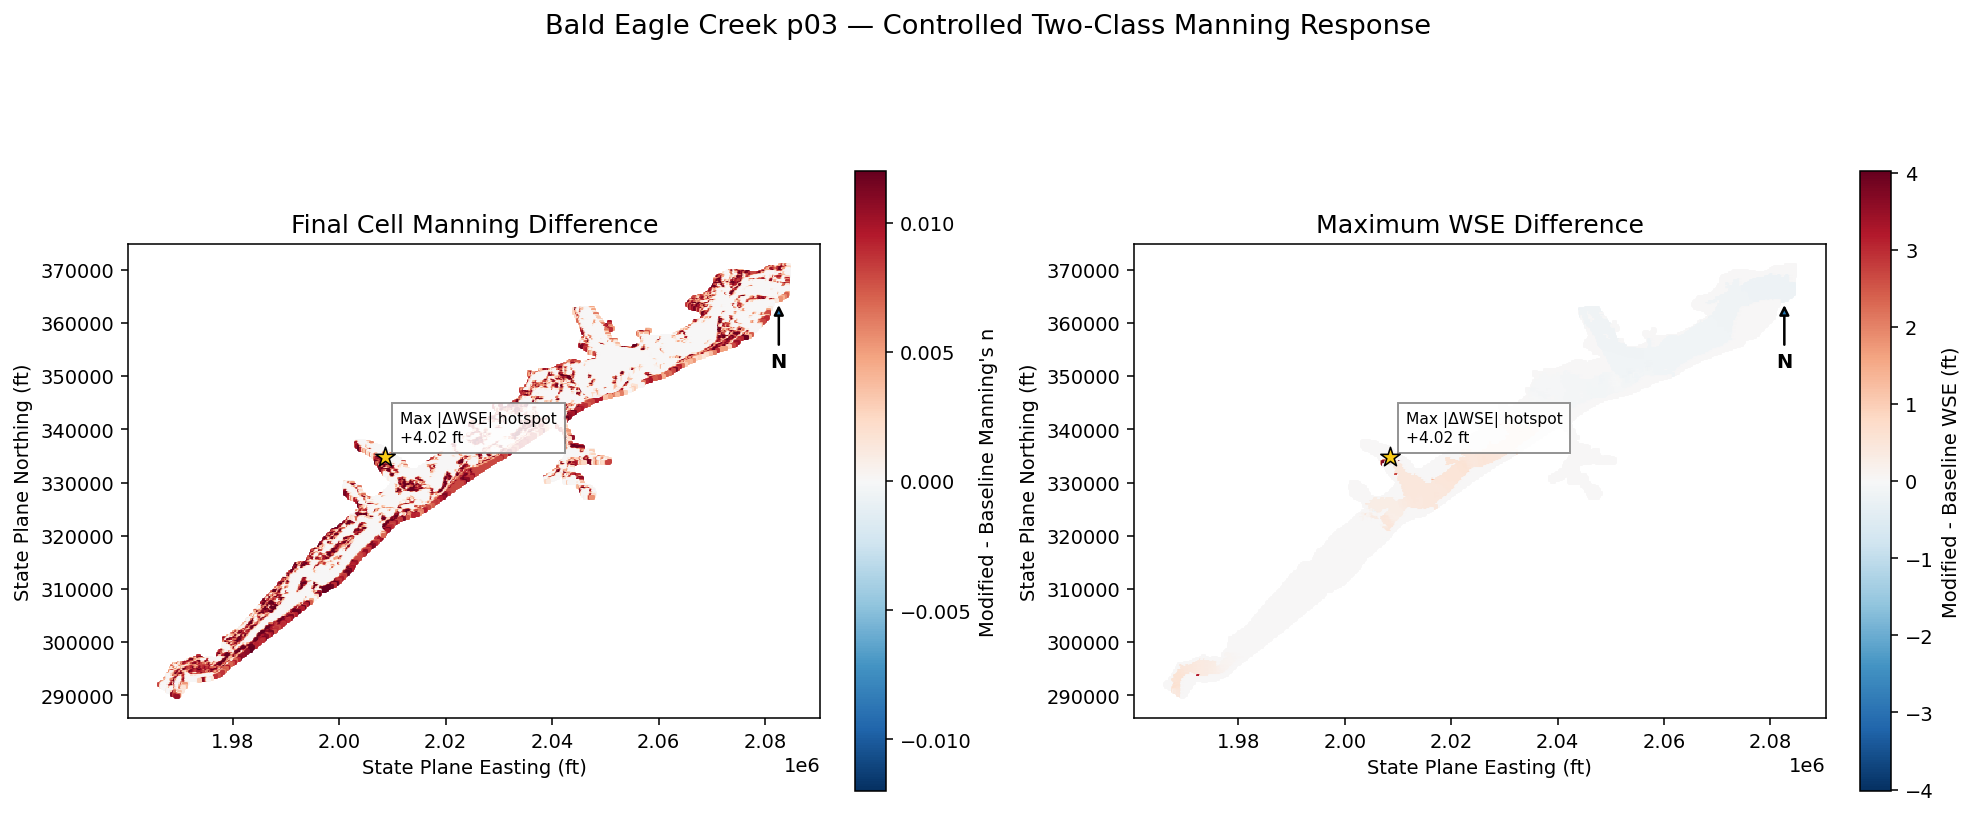

In [11]:
baseline_face_n = baseline_face["Manning's n"].to_numpy()
modified_face_n = modified_face["Manning's n"].to_numpy()
baseline_cell_n = baseline_cells["baseline_n"].to_numpy()
modified_cell_n = modified_cells["modified_n"].to_numpy()

target_count_rows = []
for class_name in STARTER_MANNINGS:
    for scenario, value, cells, faces in [
        (
            "Baseline",
            STARTER_MANNINGS[class_name],
            baseline_cell_n,
            baseline_face_n,
        ),
        (
            "Modified",
            TARGET_MANNINGS[class_name],
            modified_cell_n,
            modified_face_n,
        ),
    ]:
        cell_count = int(np.isclose(cells, value, atol=1.0e-4).sum())
        face_count = int(np.isclose(faces, value, atol=1.0e-4).sum())
        assert cell_count + face_count > 0
        target_count_rows.append(
            {
                "scenario": scenario,
                "class": class_name,
                "target n": value,
                "cell-center matches": cell_count,
                "face-profile matches": face_count,
                "composite interpretation": (
                    "exact value may occur only on face profiles"
                    if cell_count == 0
                    else "exact value occurs in cell and/or face output"
                ),
            }
        )
target_counts = pd.DataFrame(target_count_rows)
show_table(
    target_counts,
    {
        "target n": "{:.3f}",
        "cell-center matches": "{:,.0f}",
        "face-profile matches": "{:,.0f}",
    },
)

cell_audit = (
    point_identity[
        ["cell_id", "geometry_modified"]
    ]
    .rename(columns={"geometry_modified": "geometry"})
    .merge(
        baseline_cells[["cell_id", "baseline_n"]],
        on="cell_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        modified_cells[["cell_id", "modified_n"]],
        on="cell_id",
        how="left",
        validate="one_to_one",
    )
)
cell_audit["delta_n"] = (
    cell_audit["modified_n"]
    - cell_audit["baseline_n"]
)

wse_column = "maximum_water_surface"
baseline_wse_mesh = baseline_wse.loc[
    baseline_wse["mesh_name"] == MESH_NAME,
    ["cell_id", wse_column],
].rename(columns={wse_column: "baseline_wse"})
modified_wse_mesh = modified_wse.loc[
    modified_wse["mesh_name"] == MESH_NAME,
    ["cell_id", wse_column],
].rename(columns={wse_column: "modified_wse"})
cell_audit = (
    cell_audit.merge(
        baseline_wse_mesh,
        on="cell_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        modified_wse_mesh,
        on="cell_id",
        how="left",
        validate="one_to_one",
    )
)
cell_audit["delta_wse"] = (
    cell_audit["modified_wse"] - cell_audit["baseline_wse"]
)
cell_audit["active_polygon"] = cell_audit["cell_id"].isin(
    active_cell_ids
)
cell_audit["valid_result_pair"] = (
    np.isfinite(cell_audit["baseline_n"])
    & np.isfinite(cell_audit["modified_n"])
    & np.isfinite(cell_audit["baseline_wse"])
    & np.isfinite(cell_audit["modified_wse"])
    & (cell_audit["baseline_wse"] > -100)
    & (cell_audit["modified_wse"] > -100)
)
assert len(cell_audit) == 19_597
assert int(cell_audit["active_polygon"].sum()) == 18_066
assert int((~cell_audit["active_polygon"]).sum()) == 1_531
assert cell_audit.loc[
    cell_audit["active_polygon"],
    "valid_result_pair",
].all()
comparison = cell_audit.loc[
    cell_audit["active_polygon"]
    & cell_audit["valid_result_pair"]
].copy()
assert len(comparison) == 18_066

target_codes = set(
    modified_map.loc[
        modified_map["class_name"].isin(TARGET_MANNINGS),
        "pixel_value",
    ].astype(int)
)
coordinates = [
    (geometry.x, geometry.y)
    for geometry in comparison["geometry"]
]
with rasterio.open(modified_state["authored_tif"]) as source:
    sampled_codes = np.array(
        [int(value[0]) for value in source.sample(coordinates)]
    )
comparison["target_center_footprint"] = np.isin(
    sampled_codes,
    list(target_codes),
)
comparison["changed_manning"] = (
    comparison["delta_n"].abs() > 1.0e-6
)
footprint_cross_tab = pd.crosstab(
    comparison["changed_manning"].map(
        {False: "unchanged Manning", True: "changed Manning"}
    ),
    comparison["target_center_footprint"].map(
        {False: "center outside target", True: "center in target"}
    ),
    margins=True,
    margins_name="all active cells",
)
assert int(
    footprint_cross_tab.loc[
        "all active cells",
        "all active cells",
    ]
) == 18_066
outside_target_changes = int(
    footprint_cross_tab.loc[
        "changed Manning",
        "center outside target",
    ]
)
assert outside_target_changes > 0

changed_cells = int(comparison["changed_manning"].sum())
hydraulic_cells = int((comparison["delta_wse"].abs() > 1.0e-4).sum())
changed_face_rows = int(
    (
        ~np.isclose(
            shared_face["Manning's n_baseline"],
            shared_face["Manning's n_modified"],
            atol=1.0e-6,
        )
    ).sum()
)
assert changed_cells > 0
assert changed_face_rows > 0
assert hydraulic_cells > 0
assert changed_cells + int(
    (~comparison["changed_manning"]).sum()
) == 18_066

baseline_breach_summary = HdfResultsBreach.get_breach_summary(
    baseline_plan_hdf,
    BREACH_STRUCTURE,
)
modified_breach_summary = HdfResultsBreach.get_breach_summary(
    modified_plan_hdf,
    BREACH_STRUCTURE,
)
assert len(baseline_breach_summary) == 1
assert len(modified_breach_summary) == 1
assert (
    baseline_breach_summary.iloc[0]["structure"]
    == modified_breach_summary.iloc[0]["structure"]
    == BREACH_STRUCTURE
)
baseline_breach_at = pd.to_datetime(
    str(baseline_breach_summary.iloc[0]["breach_at_date"]).strip(),
    format="%d%b%Y %H:%M:%S",
)
modified_breach_at = pd.to_datetime(
    str(modified_breach_summary.iloc[0]["breach_at_date"]).strip(),
    format="%d%b%Y %H:%M:%S",
)
assert baseline_breach_at.strftime("%H:%M:%S") == "02:41:30"
assert modified_breach_at.strftime("%H:%M:%S") == "02:37:00"
breach_advance_seconds = int(
    (baseline_breach_at - modified_breach_at).total_seconds()
)
assert breach_advance_seconds == 270
breach_timing = pd.DataFrame(
    [
        {
            "scenario": "Baseline",
            "structure": BREACH_STRUCTURE,
            "HEC-RAS breach time": baseline_breach_at,
            "advance versus baseline (seconds)": 0,
        },
        {
            "scenario": "Modified",
            "structure": BREACH_STRUCTURE,
            "HEC-RAS breach time": modified_breach_at,
            "advance versus baseline (seconds)": breach_advance_seconds,
        },
    ]
)

hotspot_index = comparison["delta_wse"].abs().idxmax()
hotspot = comparison.loc[hotspot_index]
hotspot_x = hotspot["geometry"].x
hotspot_y = hotspot["geometry"].y

summary = pd.DataFrame(
    [
        ("Total HDF cell-center rows audited", f"{len(cell_audit):,}"),
        ("Active result cells compared", f"{len(comparison):,}"),
        (
            "Excluded/inactive center rows",
            f"{len(excluded_center_ids):,}",
        ),
        ("Final cell Manning rows changed", f"{changed_cells:,}"),
        (
            "Shared full-key face Manning rows changed",
            f"{changed_face_rows:,}",
        ),
        (
            "Target-center-footprint active cells",
            f"{int(comparison['target_center_footprint'].sum()):,}",
        ),
        (
            "Changed Manning outside target center",
            f"{outside_target_changes:,}",
        ),
        ("Cells with |ΔWSE| > 0.0001 ft", f"{hydraulic_cells:,}"),
        ("Mean ΔWSE", f"{comparison['delta_wse'].mean():+.3f} ft"),
        ("Minimum ΔWSE", f"{comparison['delta_wse'].min():+.3f} ft"),
        ("Maximum ΔWSE", f"{comparison['delta_wse'].max():+.3f} ft"),
        (
            "Modified breach advance",
            f"{breach_advance_seconds:,} seconds",
        ),
        ("Maximum-center shift", f"{max_center_shift:.6f} ft"),
        (
            "Face-key regeneration audit",
            (
                f"{len(shared_face):,} exact; "
                f"{unmatched_rows:,} unmatched; "
                f"{len(modified_face) - len(baseline_face):+,} net"
            ),
        ),
    ],
    columns=["metric", "value"],
)
show_table(
    footprint_cross_tab.rename_axis(
        index="Manning result"
    ).reset_index(),
    {
        "center outside target": "{:,.0f}",
        "center in target": "{:,.0f}",
        "all active cells": "{:,.0f}",
    },
)
show_table(
    breach_timing,
    {
        "HEC-RAS breach time": (
            lambda value: value.strftime("%d %b %Y %H:%M:%S")
        ),
        "advance versus baseline (seconds)": "{:,.0f}",
    },
)
show_table(summary)

n_abs = max(float(comparison["delta_n"].abs().max()), 0.005)
wse_abs = max(float(comparison["delta_wse"].abs().max()), 0.01)
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6.5),
    constrained_layout=True,
)
for ax, column, title, label, limit in [
    (
        axes[0],
        "delta_n",
        "Final Cell Manning Difference",
        "Modified - Baseline Manning's n",
        n_abs,
    ),
    (
        axes[1],
        "delta_wse",
        "Maximum WSE Difference",
        "Modified - Baseline WSE (ft)",
        wse_abs,
    ),
]:
    comparison.plot(
        column=column,
        ax=ax,
        cmap="RdBu_r",
        marker="s",
        markersize=2.5,
        legend=True,
        norm=TwoSlopeNorm(vcenter=0, vmin=-limit, vmax=limit),
        legend_kwds={"label": label, "shrink": 0.72},
    )
    ax.scatter(
        [hotspot_x],
        [hotspot_y],
        marker="*",
        s=110,
        color="#facc15",
        edgecolor="black",
        linewidth=0.8,
        zorder=5,
    )
    ax.annotate(
        f"Max |ΔWSE| hotspot\n{hotspot['delta_wse']:+.2f} ft",
        (hotspot_x, hotspot_y),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=8,
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.5"},
    )
    ax.set_title(title)
    ax.set_xlabel("State Plane Easting (ft)")
    ax.set_ylabel("State Plane Northing (ft)")
    ax.set_aspect("equal")
    ax.annotate(
        "N",
        xy=(0.94, 0.88),
        xytext=(0.94, 0.74),
        xycoords="axes fraction",
        ha="center",
        fontweight="bold",
        arrowprops={"arrowstyle": "-|>", "linewidth": 1.3},
    )
fig.suptitle(
    "Bald Eagle Creek p03 — Controlled Two-Class Manning Response",
    fontsize=14,
)
plt.show()


## Conclusions

- HEC-RAS authored identical starter NLCD layers in the two disposable
  projects.
- Both geometries used Terrain50, identical spatial/composite Manning
  settings, sidecar-derived text tables, and native recomputation.
- Only Deciduous Forest and Mixed Forest changed in the modified
  sidecar; every non-target class remained identical.
- The post-edit modified geometry text table matched its sidecar
  class-by-class.
- Both HDFs contained 19,597 center rows. Exactly 18,066
  polygon-backed active cells entered the hydraulic comparison; 1,531
  excluded/inactive center rows were retained and classified in the
  audit.
- Face IDs remained stable, but HEC-RAS regenerated the face-elevation
  sampling grid: 433,897 baseline rows versus 433,960 modified rows,
  402,362 exact full-key matches, 63,133 unmatched regenerated rows,
  and a net increase of 63.
- The changed-Manning by target-center cross-tab accounts for all
  18,066 active cells. Changes outside the target center sample are
  expected under spatial/composite face processing because cell edges
  and face profiles sample more than the single center point.
- Both HEC-RAS solves passed required-array verification, and
  solver-owned Manning and maximum-WSE results quantified the
  controlled hydraulic response.
- HEC-RAS reports breach initiation at 02:41:30 in the baseline and
  02:37:00 in the modified case, a 270-second advance. The reported
  maximum ΔWSE of about +4.02 ft therefore includes nonlinear
  amplification from the earlier elevation-triggered breach wave; it
  is not a purely local, direct roughness effect.
